In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons, make_classification

from numpy import ndarray

In [136]:
np.set_printoptions(formatter={'float_kind': '{:6.2f}'.format})

In [ ]:
n = 500
X, s = make_moons(n_samples=n, noise=0.1, random_state=42)
X, s = make_classification(n, n_features=2, n_informative=2, n_redundant=0, n_classes=2, scale=1, class_sep=0.3, shift=1)

X_train, X_val, y_train, y_val = train_test_split(X, s, test_size=0.4, stratify=s)

<Axes: >

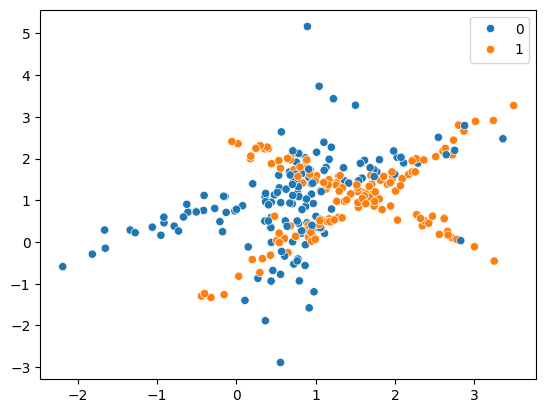

In [251]:
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train)

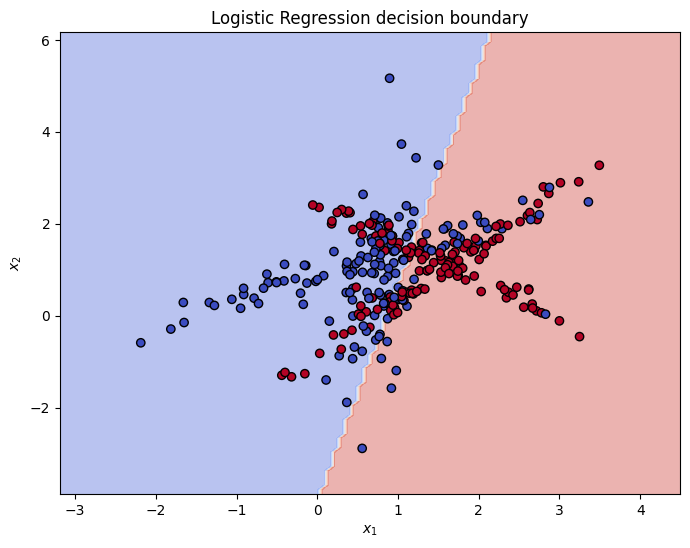

0.6866666666666666
0.69


In [252]:
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score

lr = LogisticRegression(C=10, l1_ratio=1, solver='saga', max_iter=100_000).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(8, 6))

display = DecisionBoundaryDisplay.from_estimator(lr, X_train, response_method='predict', alpha=0.4, cmap='coolwarm', ax=ax)
display.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', cmap='coolwarm')

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Logistic Regression decision boundary')
plt.show()

print(accuracy_score(y_train, lr.predict(X_train)))
print(accuracy_score(y_val, lr.predict(X_val)))